In [6]:
import os
import librosa
import soundfile as sf

input_folder = "k9sxg2twv4-4/mp3"
output_folder = "wav_clean"

os.makedirs(output_folder, exist_ok=True)

for file in os.listdir(input_folder):

    if file.endswith(".mp3"):

        path = os.path.join(input_folder, file)

        audio, sr = librosa.load(path, sr=24000)

        out_path = os.path.join(output_folder, file.replace(".mp3",".wav"))

        sf.write(out_path, audio, 24000)

print("Finished")

Finished


### Tạo file làm sạch audio

In [7]:
import os
import librosa
import soundfile as sf
import numpy as np

input_folder = "wav_clean"
output_folder = "wav_processed"

os.makedirs(output_folder, exist_ok=True)

count = 0

for file in os.listdir(input_folder):

    if file.endswith(".wav"):

        path = os.path.join(input_folder, file)

        audio, sr = librosa.load(path, sr=24000)

        # remove silence
        audio, _ = librosa.effects.trim(audio)

        # normalize volume
        audio = audio / np.max(np.abs(audio))

        duration = len(audio) / sr

        # lọc audio quá ngắn hoặc dài
        if duration < 2 or duration > 12:
            continue

        out_path = os.path.join(output_folder, file)

        sf.write(out_path, audio, sr)

        count += 1

print("Audio kept:", count)

/var/folders/2p/p4mj443j4j56m0lgzq98w6qc0000gp/T/ipykernel_31862/1541182906.py:25: RuntimeWarning: invalid value encountered in divide
  audio = audio / np.max(np.abs(audio))


Audio kept: 22444


### Kiểm tra dataset sau khi clean

In [8]:
import os
print("Total audio:", len(os.listdir("wav_processed")))

Total audio: 22444


### Thống kê độ dài audio

In [9]:
import librosa
import os
import numpy as np

durations = []

for file in os.listdir("wav_processed"):

    path = os.path.join("wav_processed", file)

    audio, sr = librosa.load(path)

    durations.append(len(audio)/sr)

print("Mean:", np.mean(durations))
print("Max:", np.max(durations))
print("Min:", np.min(durations))
print("Total hours:", sum(durations)/3600)

Mean: 4.39708443408255
Max: 11.996009070294784
Min: 2.0026757369614514
Total hours: 27.413378621818953


### Vẽ biểu đồ độ dài audio

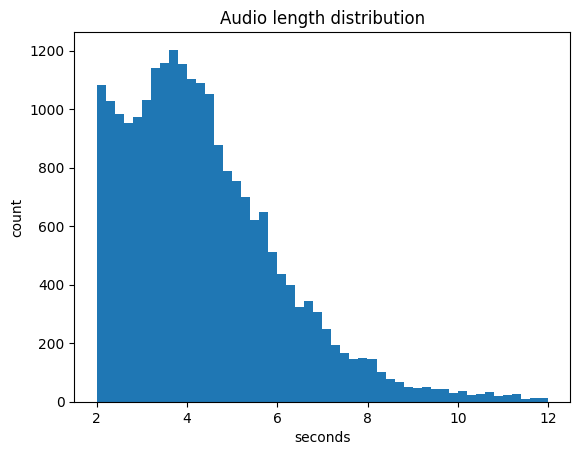

In [10]:
import matplotlib.pyplot as plt

plt.hist(durations, bins=50)
plt.xlabel("seconds")
plt.ylabel("count")
plt.title("Audio length distribution")
plt.show()

# Thống kê độ dài audio

In [12]:
import librosa
import os
import numpy as np

folder = "wav_processed"

durations = []

for file in os.listdir(folder):

    path = os.path.join(folder, file)

    audio, sr = librosa.load(path)

    duration = len(audio) / sr

    durations.append(duration)

durations = np.array(durations)

print("Number of audio:", len(durations))
print("Total duration (hours):", np.sum(durations)/3600)
print("Mean duration:", np.mean(durations))
print("Median duration:", np.median(durations))
print("Min duration:", np.min(durations))
print("Max duration:", np.max(durations))
print("Std deviation:", np.std(durations))

Number of audio: 22444
Total duration (hours): 27.4133786218191
Mean duration: 4.39708443408255
Median duration: 4.096009070294785
Min duration: 2.0026757369614514
Max duration: 11.996009070294784
Std deviation: 1.716929382990929


### Tạo bảng thống kê

In [13]:
import pandas as pd

stats = {
    "Metric": [
        "Number of audio",
        "Total duration (hours)",
        "Mean duration",
        "Median duration",
        "Min duration",
        "Max duration",
        "Std deviation"
    ],
    
    "Value": [
        len(durations),
        np.sum(durations)/3600,
        np.mean(durations),
        np.median(durations),
        np.min(durations),
        np.max(durations),
        np.std(durations)
    ]
}

df = pd.DataFrame(stats)
df

,Metric,Value
0,Number of audio,22444.000000
1,Total duration (hours),27.413379
2,Mean duration,4.397084
3,Median duration,4.096009
4,Min duration,2.002676
5,Max duration,11.996009
6,Std deviation,1.716929


### Thống kê sample rate

In [14]:
audio, sr = librosa.load("wav_processed/"+os.listdir("wav_processed")[0])

print("Sample rate:", sr)

Sample rate: 22050


### Thống kê số từ trong transcript (nếu có)

In [15]:
word_counts = []

with open("/Users/nguyencongtri/PycharmProjects/DataMining/k9sxg2twv4-4/transcriptAll.txt","r",encoding="utf-8") as f:
    
    for line in f:
        
        words = line.strip().split()
        
        word_counts.append(len(words))

print("Mean words:", np.mean(word_counts))
print("Max words:", np.max(word_counts))
print("Min words:", np.min(word_counts))

Mean words: 12.758844180394275
Max words: 70
Min words: 1
